# **U-NET**

In [ ]:
!pip install segmentation-models-pytorch

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import segmentation_models_pytorch as smp
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


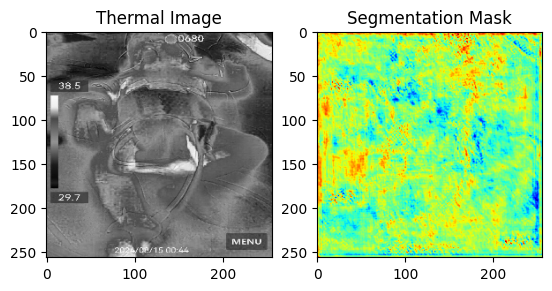

In [ ]:
# we load pre-trained U-Net
model = smp.Unet(encoder_name="resnet50",  # we use ResNet50 as the encoder
                 encoder_weights="imagenet", # it is pre-trained on ImageNet
                 in_channels=1,  # thermal images are grayscale
                 classes=1)  # binary segmentation (baby vs background)
model.eval()

# Function to preprocess and run inference
def segment_thermal_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
    image = cv2.resize(image, (256, 256))  # Resize to match model input
    image = image / 255.0  # Normalize
    image = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch & channel dim

    with torch.no_grad():
        output = model(image)  # Forward pass
        output = torch.sigmoid(output).cpu().numpy().squeeze()  # Apply sigmoid & remove batch dim

    # show
    plt.subplot(1, 2, 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title("Thermal Image")

    plt.subplot(1, 2, 2)
    plt.imshow(output, cmap="jet")
    plt.title("Segmentation Mask")

    plt.show()


segment_thermal_image("/content/PROVABEBE.jpg")


In [ ]:
!pip install segmentation-models-pytorch torch torchvision albumentations opencv-python numpy


Resnet 34 is going to be also tested as it is considered to have a strong learning ability making it suitable for specialized domains like analyzing medical scans, satellite imagery, or thermal images.

In [ ]:
import torch
import segmentation_models_pytorch as smp
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load a U-Net model pre-trained on grayscale images (similar to infrared)
model = smp.Unet(
    encoder_name="resnet34",   # Choose a ResNet34 encoder (pre-trained on ImageNet)
    encoder_weights="imagenet",  # Use ImageNet weights (RGB)
    in_channels=1,  # Infrared images are usually single-channel
    classes=1,      # Binary segmentation (background vs. person)
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()  # Set to evaluation mode


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 188MB/s]


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read infrared image
    image = cv2.resize(image, (256, 256))  # Resize to match model input
    image = image.astype(np.float32) / 255.0  # Normalize to [0, 1]
    image = np.expand_dims(image, axis=0)  # Add channel dimension (C, H, W)
    return torch.tensor(image).unsqueeze(0).to(device)  # Convert to tensor & add batch dim


image_path = "/content/PROVABEBE.jpg"
input_tensor = preprocess_image(image_path)


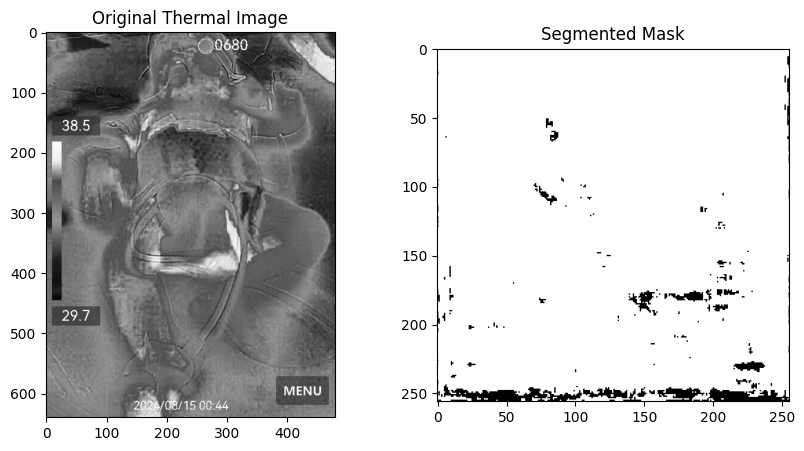

In [ ]:
with torch.no_grad():
    output = model(input_tensor)
    mask = torch.sigmoid(output).cpu().numpy().squeeze()

# Convert mask to binary (0 or 1)
threshold = 0.5
binary_mask = (mask > threshold).astype(np.uint8)


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap="gray")
plt.title("Original Thermal Image")
plt.subplot(1, 2, 2)
plt.imshow(binary_mask, cmap="gray")
plt.title("Segmented Mask")
plt.show()


# **Conclusions**

The model, a U-Net with a ResNet34 encoder pre-trained on ImageNet, performed poorly on thermal images of babies. This is likely due to the mismatch between the RGB-based pretraining and the single-channel thermal data, as well as the lack of fine-tuning on domain-specific images. Additionally, note that thermal images have low contrast and subtle features that the model was not trained to recognize.

A similar attempt using ResNet50 as the encoder also failed to produce satisfactory results, likely for the same reasons: despite being deeper, it was still pre-trained on RGB data and lacked this needed adaptation to thermal images of babies.